# Experiment: CyEmbed Archetype Embedding Analysis

Interpretation and QC notebook for one saved run from `01_archetype_embedding_sweep.ipynb`.

Sections A-I:
- A. Reconstruction QC
- B. Archetype profiles
- C. Per-cell weights
- D. Sample-level summaries
- E. Cluster-level summaries
- F. UMAP overlays
- G. Marker embedding analysis
- H. Archetype embedding analysis
- I. Residual analysis


In [41]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from CyEmbed.analysis import (
    archetype_marker_rankings,
    cosine_similarity_matrix,
    dominant_assignments,
    kl_history_columns,
    load_run_outputs,
    nearest_neighbors_from_similarity,
    pairwise_distance_matrix,
    pca_projection,
    per_marker_reconstruction_stats,
    posterior_mean_weights,
    purity_summary,
    residual_norms,
    residual_summary,
    summarize_by_group,
    umap_projection,
    weight_entropy,
)
from CyEmbed.plotting import (
    plot_embedding_scatter,
    plot_clustermap,
    plot_matrix_heatmap,
    plot_observed_vs_reconstructed,
    plot_umap_categorical,
    plot_umap_overlay,
    plot_weight_histograms,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


sns.set_theme(context="notebook", style="whitegrid")


In [42]:
# === Editable configuration ===
SWEEP_ROOT = Path("outputs/archetype_embedding_sweep_lowK/")
RUN_DIR = None  # Optional explicit run dir path
RUN_ID = None   # Optional explicit run_id (used when RUN_DIR is None)

ANALYSIS_OUTDIR = Path("outputs/archetype_embedding_analysis")
ANALYSIS_OUTDIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_CFG = {
    "top_n_markers": 12,
    "scatter_markers": None,  # None -> pick top markers by R2
    "row_zscore_archetype_heatmap": True,
    "max_umap_panels": 12,

    # Run discovery/selection while sweep is still running
    # Options: "composite" or any column from runs_df (e.g. "val_recon")
    "run_selection_metric": "composite",
    "require_no_dead_archetypes": True,
    "dead_archetype_threshold": 0,
    "composite_weights": {
        "val_recon": 1.0,
        "dead_archetypes": 2.0,
        "usage_std": 0.5,
        "mean_entropy": 0.25,
        "purity": 0.25,
    },

    # Optional AnnData path for UMAP overlays / conditions
    "adata_path": "/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/levine32_processed.h5ad",
    "condition_col": None,
}


In [43]:
# === Load run outputs ===
required_files = [
    "config.json",
    "summary_metrics.json",
    "history.csv",
    "X_observed.npy",
    "X_hat.npy",
    "W.npy",
    "A_hat.npy",
    "marker_names.csv",
    "cell_ids.csv",
]


def _discover_completed_runs(sweep_root: Path) -> pd.DataFrame:
    run_records = []
    if not sweep_root.exists():
        return pd.DataFrame()

    for run_dir in sorted([d for d in sweep_root.iterdir() if d.is_dir()]):
        if not all((run_dir / f).exists() for f in required_files):
            continue

        try:
            with (run_dir / "config.json").open("r", encoding="utf-8") as f:
                cfg = json.load(f)
            with (run_dir / "summary_metrics.json").open("r", encoding="utf-8") as f:
                sm = json.load(f)
            history = pd.read_csv(run_dir / "history.csv")
        except Exception as exc:
            print(f"Skipping unreadable run folder {run_dir.name}: {exc}")
            continue

        val_summary = sm.get("val", {})
        val_recon = sm.get("best_val_recon", sm.get("final_val_recon", np.nan))
        run_records.append(
            {
                "run_id": sm.get("run_id", run_dir.name),
                "run_dir": str(run_dir.resolve()),
                "model_type": cfg.get("model_type", "deterministic"),
                "decoder_type": cfg.get("decoder_type"),
                "use_residual_latent": cfg.get("use_residual_latent", False),
                "K": cfg.get("K"),
                "d": cfg.get("d"),
                "hidden_dims": cfg.get("hidden_dims"),
                "lr": cfg.get("lr"),
                "batch_size": cfg.get("batch_size"),
                "recon_loss_type": cfg.get("recon_loss_type"),
                "tau": cfg.get("tau"),
                "patience": cfg.get("patience"),
                "beta_w": cfg.get("beta_w", np.nan),
                "beta_r": cfg.get("beta_r", np.nan),
                "residual_dim": cfg.get("residual_dim", np.nan),
                "best_epoch": sm.get("best_epoch", np.nan),
                "stopped_early": sm.get("stopped_early", np.nan),
                "val_recon": val_recon,
                "final_val_recon": sm.get("final_val_recon", np.nan),
                "final_kl_w": sm.get("final_kl_w", np.nan),
                "final_kl_r": sm.get("final_kl_r", np.nan),
                "dead_archetypes": val_summary.get("dead_archetypes_lt_1pct", np.nan),
                "usage_std": val_summary.get("usage_std", np.nan),
                "mean_entropy": val_summary.get("mean_weight_entropy", np.nan),
                "purity_gt_08": val_summary.get("dominant_frac_gt_0_8", np.nan),
                "n_epochs_completed": int(history["epoch"].max()) if "epoch" in history.columns and len(history) > 0 else 0,
            }
        )

    if not run_records:
        return pd.DataFrame()

    runs_df = pd.DataFrame(run_records)
    return runs_df


def _add_composite_score(runs_df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    w = cfg["composite_weights"]
    out = runs_df.copy()
    out["composite_score"] = (
        w["val_recon"] * out["val_recon"].astype(float)
        + w["dead_archetypes"] * out["dead_archetypes"].astype(float)
        + w["usage_std"] * out["usage_std"].astype(float)
        + w["mean_entropy"] * out["mean_entropy"].astype(float)
        - w["purity"] * out["purity_gt_08"].astype(float)
    )
    return out


runs_df = _discover_completed_runs(SWEEP_ROOT)
if runs_df.empty:
    raise FileNotFoundError(
        f"No completed runs found in {SWEEP_ROOT}. "
        "Start the sweep notebook first, or wait for at least one run to finish."
    )

runs_df = _add_composite_score(runs_df, ANALYSIS_CFG)

eligible_df = runs_df.copy()
if ANALYSIS_CFG.get("require_no_dead_archetypes", True):
    thr = ANALYSIS_CFG.get("dead_archetype_threshold", 0)
    filtered = eligible_df.loc[eligible_df["dead_archetypes"].fillna(np.inf) <= thr].copy()
    if not filtered.empty:
        eligible_df = filtered
    else:
        print("Warning: no runs satisfy the no-dead-archetype constraint; falling back to all completed runs.")

metric = ANALYSIS_CFG.get("run_selection_metric", "composite")
if metric == "composite":
    sort_col = "composite_score"
else:
    sort_col = metric
    if sort_col not in eligible_df.columns:
        raise ValueError(f"run_selection_metric={metric} is not a valid runs_df column.")

runs_ranked = eligible_df.sort_values(sort_col, ascending=True).reset_index(drop=True)
runs_snapshot_path = ANALYSIS_OUTDIR / "available_runs_snapshot.csv"
runs_ranked.to_csv(runs_snapshot_path, index=False)
print(f"Discovered completed runs: {len(runs_df)} | eligible for selection: {len(eligible_df)}")
print(f"Selection metric: {sort_col}")
print(f"Saved ranked run snapshot: {runs_snapshot_path}")
display(runs_ranked)

if RUN_DIR is not None:
    RUN_DIR = Path(RUN_DIR)
elif RUN_ID is not None:
    selected = runs_ranked.loc[runs_ranked["run_id"].astype(str) == str(RUN_ID)]
    if selected.empty:
        raise ValueError(f"RUN_ID={RUN_ID} was not found among ranked runs.")
    RUN_DIR = Path(selected.iloc[0]["run_dir"])
else:
    RUN_DIR = Path(runs_ranked.iloc[0]["run_dir"])

run = load_run_outputs(RUN_DIR)
X = run["X_observed"]
X_hat = run["X_hat"]
marker_names = run["marker_names"]
cell_ids = run["cell_ids"]

W_sample = run.get("W_sample", run.get("W"))
if run.get("W_mean") is not None:
    W_mean = run["W_mean"]
elif run.get("mu_w") is not None:
    tau_val = float(run["config"].get("tau", 1.0))
    W_mean = posterior_mean_weights(run["mu_w"], tau=tau_val)
else:
    W_mean = None
W = W_mean if W_mean is not None else W_sample

A_hat = run["A_hat"]
sample_ids = run.get("sample_ids")
cluster_ids = run.get("cluster_ids")

print(f"Selected run dir: {RUN_DIR}")
print(f"Model type: {run['config'].get('model_type', 'deterministic')}")
print(f"Decoder: {run['config']['decoder_type']}")
print(f"Use residual latent: {run['config'].get('use_residual_latent', False)}")
print(f"X shape: {X.shape}")
print(f"W shape (analysis): {W.shape}")
print(f"A_hat shape: {A_hat.shape}")

history_df = run["history"]
per_marker_df = per_marker_reconstruction_stats(X, X_hat, marker_names)
dom_df = dominant_assignments(W, cell_ids=cell_ids)
purity_df = purity_summary(W)

display(per_marker_df.head(15))
display(purity_df)


Discovered completed runs: 12
Saved run snapshot: outputs/archetype_embedding_analysis/available_runs_snapshot.csv


,run_id,run_dir,decoder_type,K,d,hidden_dims,lr,batch_size,recon_loss_type,tau,patience,best_epoch,stopped_early,val_recon,final_val_recon,n_epochs_completed
0,run011_20260416_094217,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,6,12,"[256, 128]",0.001,2048,mse,1.0,20,80,False,0.495432,0.495432,80
1,run009_20260416_094123,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,6,8,"[256, 128]",0.001,2048,mse,1.0,20,80,False,0.543594,0.543594,80
2,run007_20260416_094030,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,6,4,"[256, 128]",0.001,2048,mse,1.0,20,80,False,0.550471,0.550471,80
3,run010_20260416_094150,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,6,8,"[256, 128]",0.001,2048,mse,1.0,20,80,False,0.555133,0.555133,80
4,run003_20260416_093842,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,4,8,"[256, 128]",0.001,2048,mse,1.0,20,79,False,0.601368,0.601400,80
5,run005_20260416_093936,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,4,12,"[256, 128]",0.001,2048,mse,1.0,20,79,False,0.601381,0.601384,80
6,run006_20260416_094004,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,4,12,"[256, 128]",0.001,2048,mse,1.0,20,80,False,0.601581,0.601581,80
7,run004_20260416_093909,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,4,8,"[256, 128]",0.001,2048,mse,1.0,20,80,False,0.601650,0.601650,80
8,run001_20260416_093748,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,4,4,"[256, 128]",0.001,2048,mse,1.0,20,80,False,0.601900,0.601900,80
9,run012_20260416_094243,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/C...,factorized,6,12,"[256, 128]",0.001,2048,mse,1.0,20,79,False,0.687200,0.687689,80


Selected run dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/CyEmbed/outputs/archetype_embedding_sweep_lowK/run011_20260416_094217
X shape: (104184, 32)
W shape: (104184, 6)
A_hat shape: (6, 32)
Decoder: factorized


,marker,pearson_r,spearman_r,r2,mse,mae
0,CD19,0.920662,0.609707,0.847580,0.152421,0.286082
1,CD11c,0.915573,0.659674,0.838141,0.161863,0.289143
2,CD3,0.914035,0.784845,0.835293,0.164707,0.300891
3,CD11b,0.896039,0.663578,0.802708,0.197291,0.326453
4,HLA-DR,0.880043,0.824533,0.774457,0.225546,0.335577
5,CD64,0.876835,0.639754,0.768672,0.231328,0.317646
6,CD22,0.876703,0.601115,0.768605,0.231399,0.339416
7,CD45,0.876318,0.787616,0.767889,0.232115,0.363109
8,CD20,0.816567,0.569509,0.666775,0.333225,0.383077
9,CD38,0.773540,0.732552,0.598223,0.401780,0.472735


,threshold,fraction_cells
0,0.5,0.166590
1,0.8,0.000077


In [ ]:
# === Probabilistic diagnostics ===
is_probabilistic = str(run["config"].get("model_type", "deterministic")).lower() == "probabilistic"
if not is_probabilistic:
    print("Deterministic run: probabilistic diagnostics are not applicable.")
else:
    print("Probabilistic run detected.")

    # 1) Sampled-vs-posterior-mean simplex weights.
    if W_sample is not None and W_mean is not None:
        w_abs_diff = np.abs(W_sample - W_mean)
        print(f"Mean |W_sample - W_mean|: {w_abs_diff.mean():.6f}")
        print(f"Median |W_sample - W_mean|: {np.median(w_abs_diff):.6f}")

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.histplot(w_abs_diff.ravel(), bins=80, ax=ax, color="tab:purple")
        ax.set_title("|W_sample - W_mean| distribution")
        ax.set_xlabel("Absolute difference")
        plt.tight_layout()

    # 2) KL tracking during optimization.
    kl_cols = kl_history_columns(history_df)
    if kl_cols:
        fig, ax = plt.subplots(figsize=(7, 4))
        for col in kl_cols:
            ax.plot(history_df["epoch"], history_df[col], label=col)
        ax.set_title("KL terms across training")
        ax.set_xlabel("Epoch")
        ax.legend(frameon=False)
        plt.tight_layout()
    else:
        print("No KL columns found in history.")

    # 3) Posterior variance of archetype logits q(U|X): var = exp(logvar_w).
    if run.get("logvar_w") is not None:
        logvar_w = np.asarray(run["logvar_w"], dtype=np.float32)
        var_w = np.exp(np.clip(logvar_w, -20.0, 20.0))

        print(f"logvar_w mean: {logvar_w.mean():.6f} | median: {np.median(logvar_w):.6f}")
        print(f"var_w mean: {var_w.mean():.6f} | median: {np.median(var_w):.6f}")

        per_arch_df = pd.DataFrame({
            "archetype": [f"A{k}" for k in range(logvar_w.shape[1])],
            "mean_logvar_w": logvar_w.mean(axis=0),
            "mean_var_w": var_w.mean(axis=0),
            "median_var_w": np.median(var_w, axis=0),
        })
        display(per_arch_df)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(logvar_w.ravel(), bins=80, ax=axes[0], color="tab:blue")
        axes[0].set_title("logvar_w distribution")
        axes[0].set_xlabel("logvar_w")

        sns.histplot(var_w.ravel(), bins=80, ax=axes[1], color="tab:orange")
        axes[1].set_title("var_w = exp(logvar_w) distribution")
        axes[1].set_xlabel("var_w")
        plt.tight_layout()

        fig, ax = plt.subplots(figsize=(max(6, 0.7 * logvar_w.shape[1]), 3.8))
        sns.barplot(data=per_arch_df, x="archetype", y="mean_var_w", ax=ax, color="tab:orange")
        ax.set_title("Mean posterior logit variance per archetype")
        ax.set_ylabel("mean var_w")
        ax.set_xlabel("archetype")
        plt.tight_layout()
    else:
        print("No logvar_w saved for this run.")

    # 4) Optional residual latent diagnostics.
    if run.get("R") is not None or run.get("R_sample") is not None:
        r_for_norm = run.get("R") if run.get("R") is not None else run.get("R_sample")
        r_norm = residual_norms(r_for_norm)
        print(f"Residual norm mean: {r_norm.mean():.6f}")
        print(f"Residual norm median: {np.median(r_norm):.6f}")

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.histplot(r_norm, bins=80, ax=ax, color="tab:green")
        ax.set_title("Residual latent norm distribution")
        ax.set_xlabel("||R||")
        plt.tight_layout()

        if run.get("logvar_r") is not None:
            logvar_r = np.asarray(run["logvar_r"], dtype=np.float32)
            var_r = np.exp(np.clip(logvar_r, -20.0, 20.0))
            print(f"logvar_r mean: {logvar_r.mean():.6f} | median: {np.median(logvar_r):.6f}")
            print(f"var_r mean: {var_r.mean():.6f} | median: {np.median(var_r):.6f}")

            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            sns.histplot(logvar_r.ravel(), bins=80, ax=axes[0], color="tab:cyan")
            axes[0].set_title("logvar_r distribution")
            axes[0].set_xlabel("logvar_r")

            sns.histplot(var_r.ravel(), bins=80, ax=axes[1], color="tab:red")
            axes[1].set_title("var_r = exp(logvar_r) distribution")
            axes[1].set_xlabel("var_r")
            plt.tight_layout()

        if sample_ids is not None:
            sample_resid = pd.DataFrame({"sample": sample_ids, "residual_norm": r_norm})
            sample_resid_summary = sample_resid.groupby("sample", dropna=False)["residual_norm"].mean().reset_index()
            display(sample_resid_summary.sort_values("residual_norm", ascending=False).head(20))

        if cluster_ids is not None:
            cluster_resid = pd.DataFrame({"cluster": cluster_ids, "residual_norm": r_norm})
            cluster_resid_summary = cluster_resid.groupby("cluster", dropna=False)["residual_norm"].mean().reset_index()
            display(cluster_resid_summary.sort_values("residual_norm", ascending=False).head(20))
    else:
        print("No residual latent arrays found for this run.")

    # Note: robust Var(W) requires multiple posterior samples per cell.
    if run.get("W_sample") is not None and run.get("W_mean") is not None:
        print("Tip: for stronger simplex-uncertainty estimates, evaluate with multiple MC samples and store per-cell Var(W).")


,marker,pearson_r,spearman_r,r2,mse,mae
0,CD19,0.920662,0.609707,0.847580,0.152421,0.286082
1,CD11c,0.915573,0.659674,0.838141,0.161863,0.289143
2,CD3,0.914035,0.784845,0.835293,0.164707,0.300891
3,CD11b,0.896039,0.663578,0.802708,0.197291,0.326453
4,HLA-DR,0.880043,0.824533,0.774457,0.225546,0.335577
5,CD64,0.876835,0.639754,0.768672,0.231328,0.317646
6,CD22,0.876703,0.601115,0.768605,0.231399,0.339416
7,CD45,0.876318,0.787616,0.767889,0.232115,0.363109
8,CD20,0.816567,0.569509,0.666775,0.333225,0.383077
9,CD38,0.773540,0.732552,0.598223,0.401780,0.472735


,marker,pearson_r,spearman_r,r2,mse,mae
31,Flt3,0.339698,0.345161,0.115059,0.884955,0.546881
30,CD16,0.346737,0.182349,0.119973,0.880080,0.483115
29,CD123,0.489932,0.429210,0.240004,0.760000,0.492884
28,CD133,0.525584,0.515331,0.276103,0.723902,0.606068
27,CD235ab,0.525758,0.550426,0.276370,0.723644,0.622637
26,CD14,0.540879,0.381105,0.291745,0.708262,0.521311
25,CD45RA,0.540569,0.529733,0.292148,0.707862,0.657619
24,CXCR4,0.574211,0.542674,0.329520,0.670489,0.653593
23,CD15,0.597488,0.626085,0.356659,0.643346,0.576468
22,CD7,0.619541,0.686858,0.383675,0.616330,0.549075


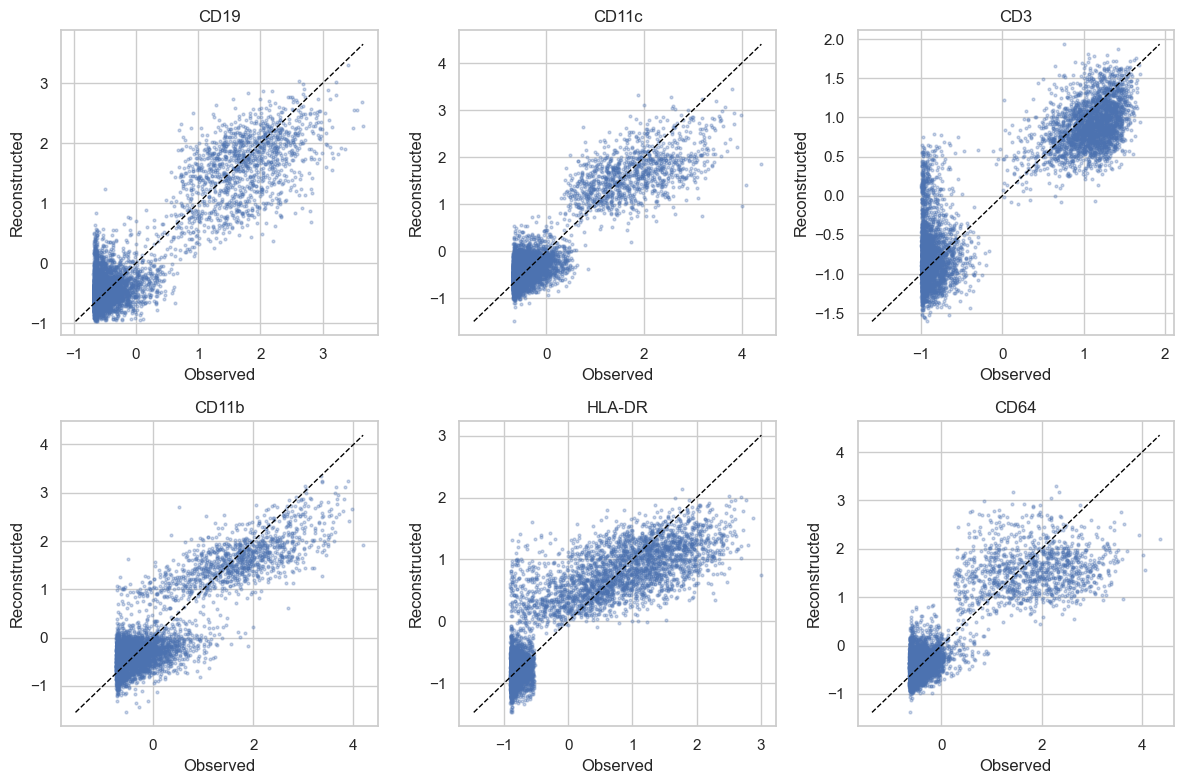

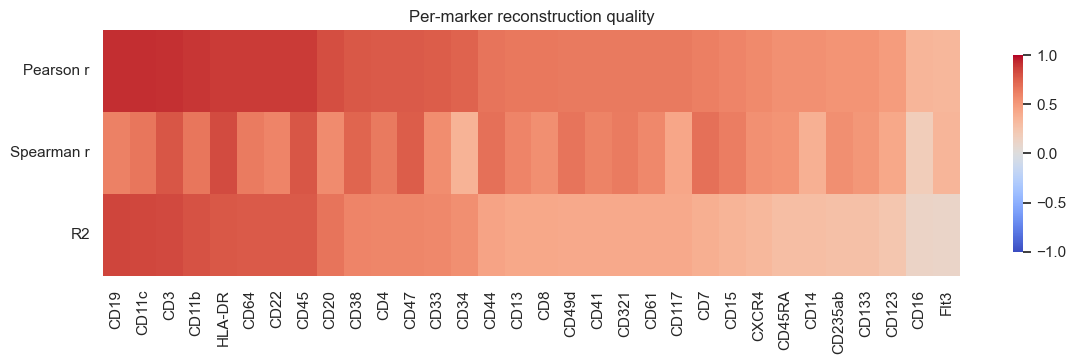

In [44]:
# === A) Reconstruction QC ===
selected_markers = ANALYSIS_CFG["scatter_markers"]
if selected_markers is None:
    selected_markers = per_marker_df.head(min(6, len(marker_names)))["marker"].tolist()

plot_observed_vs_reconstructed(
    X,
    X_hat,
    marker_names=marker_names,
    markers=selected_markers,
    max_points=6000,
    random_state=7,
)

qc_heat = per_marker_df.set_index("marker")[["pearson_r", "spearman_r", "r2"]].T.to_numpy()
plot_matrix_heatmap(
    qc_heat,
    row_labels=["Pearson r", "Spearman r", "R2"],
    col_labels=per_marker_df["marker"].tolist(),
    title="Per-marker reconstruction quality",
    cmap="coolwarm",
    figsize=(max(12, len(marker_names) * 0.3), 3.8),
    vmin=-1,
    vmax=1,
)

display(per_marker_df.sort_values("r2", ascending=False).head(20))
display(per_marker_df.sort_values("r2", ascending=True).head(20))


Saved marker ranking table to: outputs/archetype_embedding_analysis/archetype_marker_rankings.csv


,archetype,direction,rank,marker,value
0,0,positive,1,CD38,5.851136
1,0,positive,2,CD34,5.212186
2,0,positive,3,CD47,4.602336
3,0,positive,4,CD117,3.824801
4,0,positive,5,CD123,3.534603
5,0,positive,6,CXCR4,2.531916
6,0,positive,7,CD13,2.230702
7,0,positive,8,HLA-DR,2.126599
8,0,positive,9,CD321,1.876076
9,0,positive,10,CD33,1.065633


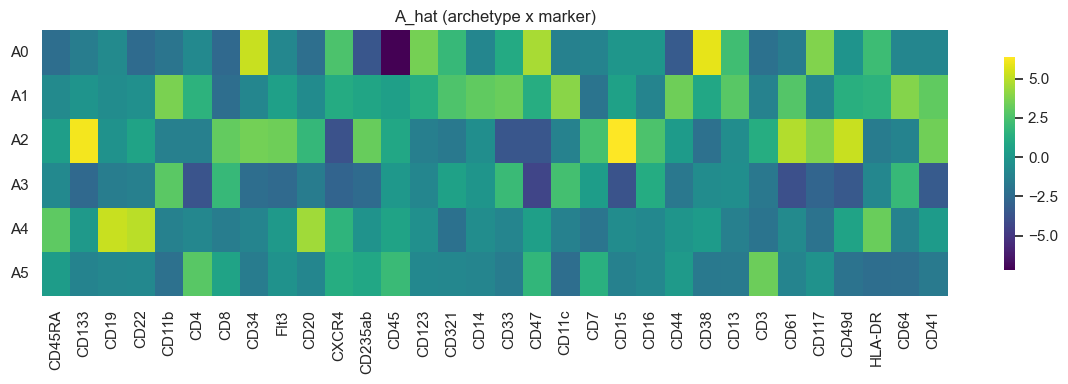

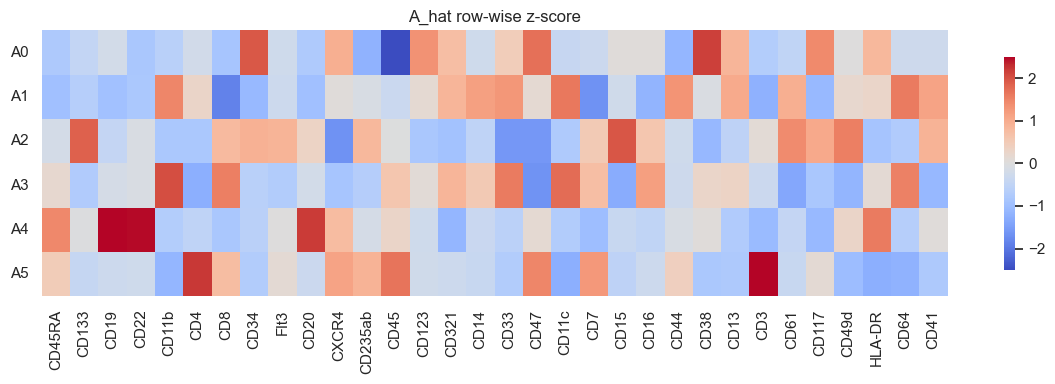

In [45]:
# === B) Archetype profiles ===
plot_matrix_heatmap(
    A_hat,
    row_labels=[f"A{k}" for k in range(A_hat.shape[0])],
    col_labels=marker_names,
    title="A_hat (archetype x marker)",
    cmap="viridis",
    figsize=(max(12, len(marker_names) * 0.35), max(4, A_hat.shape[0] * 0.35)),
)

if ANALYSIS_CFG["row_zscore_archetype_heatmap"]:
    row_mean = A_hat.mean(axis=1, keepdims=True)
    row_std = np.maximum(A_hat.std(axis=1, keepdims=True), 1e-8)
    A_row_z = (A_hat - row_mean) / row_std
    plot_matrix_heatmap(
        A_row_z,
        row_labels=[f"A{k}" for k in range(A_hat.shape[0])],
        col_labels=marker_names,
        title="A_hat row-wise z-score",
        cmap="coolwarm",
        figsize=(max(12, len(marker_names) * 0.35), max(4, A_hat.shape[0] * 0.35)),
        vmin=-2.5,
        vmax=2.5,
    )

ranking_df = archetype_marker_rankings(
    A_hat,
    marker_names=marker_names,
    top_n=int(ANALYSIS_CFG["top_n_markers"]),
)
ranking_path = ANALYSIS_OUTDIR / "archetype_marker_rankings.csv"
ranking_df.to_csv(ranking_path, index=False)
print(f"Saved marker ranking table to: {ranking_path}")

display(ranking_df.head(40))


,n_cells
dominant_archetype,
0,8879
1,19821
2,1716
3,5533
4,20519
5,47716


,threshold,fraction_cells
0,0.5,0.166590
1,0.8,0.000077


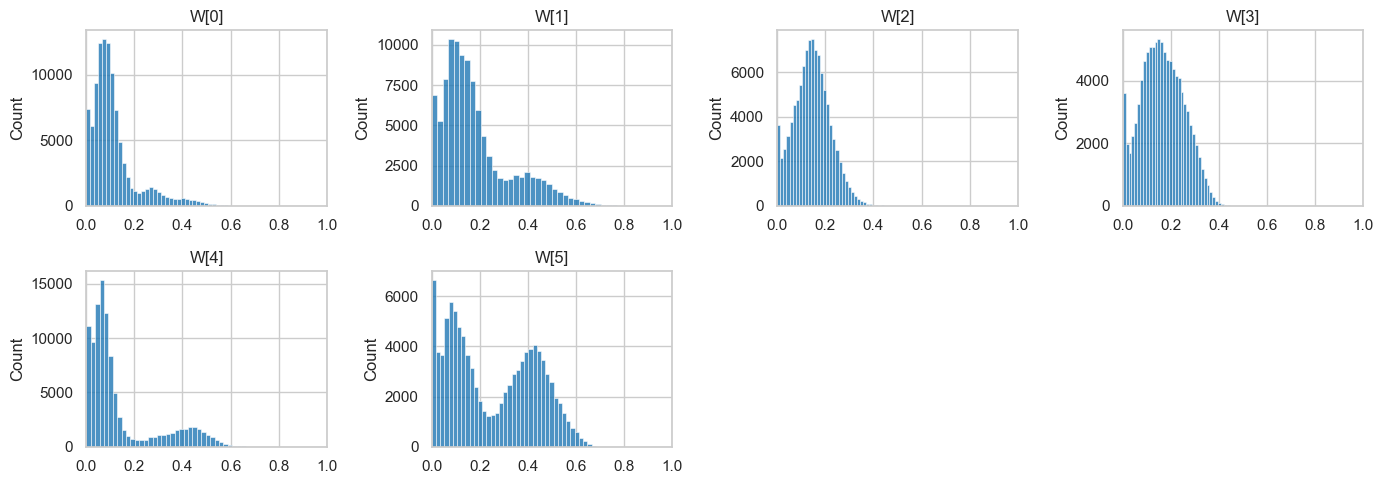

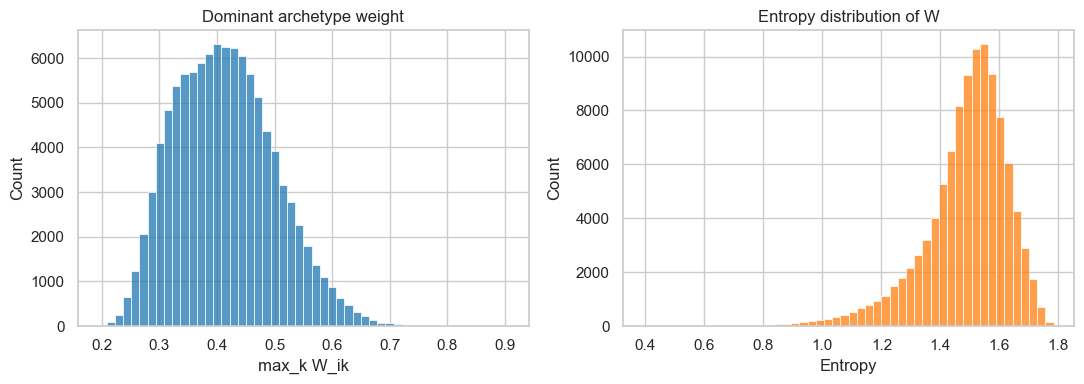

In [46]:
# === C) Per-cell weights ===
plot_weight_histograms(W)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(dom_df["dominant_weight"], bins=50, ax=axes[0], color="tab:blue")
axes[0].set_title("Dominant archetype weight")
axes[0].set_xlabel("max_k W_ik")

sns.histplot(dom_df["entropy"], bins=50, ax=axes[1], color="tab:orange")
axes[1].set_title("Entropy distribution of W")
axes[1].set_xlabel("Entropy")
plt.tight_layout()

dom_counts = dom_df["dominant_archetype"].value_counts().sort_index()
display(dom_counts.to_frame("n_cells"))
display(purity_df)


In [47]:
# === D) Sample-level summaries ===
if sample_ids is None:
    print("No sample IDs found in saved outputs; skipping sample-level analysis.")
else:
    sample_stats = summarize_by_group(W, sample_ids, group_name="sample")
    sample_mean = sample_stats["mean_weights"]
    sample_dom = sample_stats["dominant_fractions"]

    display(sample_mean.head())
    display(sample_dom.head())

    sample_mean_matrix = sample_mean.set_index("sample").to_numpy()
    plot_matrix_heatmap(
        sample_mean_matrix,
        row_labels=sample_mean["sample"].astype(str).tolist(),
        col_labels=[c for c in sample_mean.columns if c != "sample"],
        title="Mean archetype weights per sample",
        cmap="magma",
        figsize=(8, max(4, sample_mean.shape[0] * 0.4)),
    )

    # Optional condition-level boxplots if adata + condition column provided.
    if ANALYSIS_CFG["adata_path"] is not None and ANALYSIS_CFG["condition_col"] is not None:
        import anndata as ad

        adata = ad.read_h5ad(ANALYSIS_CFG["adata_path"])
        obs = adata.obs.copy()
        if ANALYSIS_CFG["condition_col"] in obs.columns and "sample" in sample_mean.columns:
            map_df = obs[[ANALYSIS_CFG["condition_col"]]].copy()
            map_df["sample"] = obs.index.astype(str)
            # This assumes sample IDs are comparable to obs index or have been pre-mapped.
            print("Condition boxplots may require custom sample-to-condition mapping for your dataset.")


No sample IDs found in saved outputs; skipping sample-level analysis.


,cluster,archetype_0,archetype_1,archetype_2,archetype_3,archetype_4,archetype_5
0,Basophils,0.284087,0.224127,0.090423,0.117067,0.095743,0.188552
1,CD16+_NK_cells,0.133922,0.034106,0.248730,0.302471,0.068674,0.212098
2,CD16-_NK_cells,0.113800,0.072251,0.177207,0.243996,0.095352,0.297395
3,CD34+CD38+CD123+_HSPCs,0.416453,0.171838,0.128275,0.055168,0.150316,0.077950
4,CD34+CD38+CD123-_HSPCs,0.432520,0.108271,0.225636,0.108108,0.067009,0.058455


,cluster,dominant_archetype,n_cells,fraction
0,Basophils,0,817,0.676885
1,Basophils,1,286,0.236951
2,Basophils,2,2,0.001657
3,Basophils,3,39,0.032312
4,Basophils,5,63,0.052196


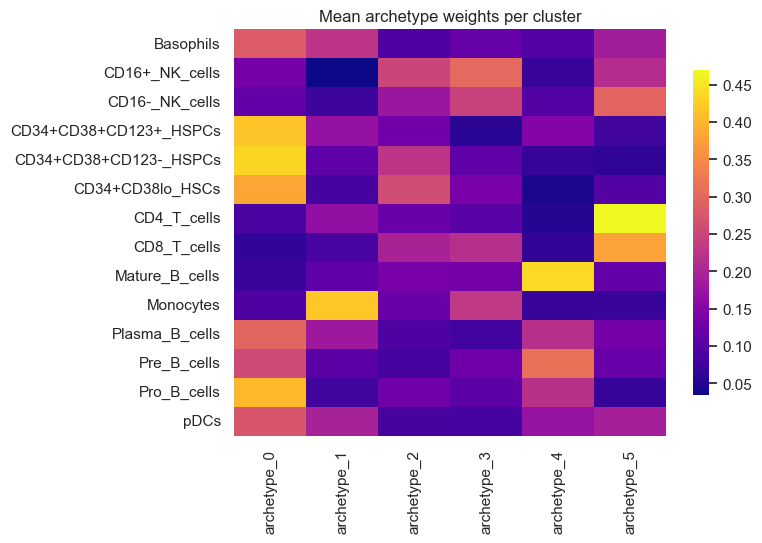

In [48]:
# === E) Cluster-level summaries ===
if cluster_ids is None:
    print("No cluster IDs found in saved outputs; skipping cluster-level analysis.")
else:
    cluster_stats = summarize_by_group(W, cluster_ids, group_name="cluster")
    cluster_mean = cluster_stats["mean_weights"]
    cluster_dom = cluster_stats["dominant_fractions"]

    display(cluster_mean.head())
    display(cluster_dom.head())

    cluster_mean_matrix = cluster_mean.set_index("cluster").to_numpy()
    plot_matrix_heatmap(
        cluster_mean_matrix,
        row_labels=cluster_mean["cluster"].astype(str).tolist(),
        col_labels=[c for c in cluster_mean.columns if c != "cluster"],
        title="Mean archetype weights per cluster",
        cmap="plasma",
        figsize=(8, max(4, cluster_mean.shape[0] * 0.4)),
    )


In [49]:
# === F) UMAP overlays ===
umap_xy = None
if ANALYSIS_CFG["adata_path"] is not None:
    try:
        import anndata as ad

        adata = ad.read_h5ad(ANALYSIS_CFG["adata_path"])
        if "X_umap" in adata.obsm:
            umap_df = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names)
            # Align to run cell order if possible.
            common = [c for c in cell_ids if c in umap_df.index]
            if len(common) == len(cell_ids):
                umap_xy = umap_df.loc[cell_ids].to_numpy()
            elif len(common) > 0:
                print("Partial overlap between run cells and adata.obs_names; using matched subset only.")
                keep_mask = np.array([c in umap_df.index for c in cell_ids])
                umap_xy = umap_df.loc[np.array(cell_ids)[keep_mask]].to_numpy()
                W = W[keep_mask]
                dom_df = dom_df.loc[keep_mask].reset_index(drop=True)
            else:
                print("No matching cell IDs between run outputs and adata.obs_names.")
    except Exception as exc:
        print(f"Unable to load UMAP from AnnData: {exc}")

if umap_xy is None:
    print("UMAP unavailable (set ANALYSIS_CFG['adata_path'] with .obsm['X_umap']).")
else:
    n_panels = min(W.shape[1], int(ANALYSIS_CFG["max_umap_panels"]))
    n_cols = 4
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.3 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for k in range(n_panels):
        sc = axes[k].scatter(umap_xy[:, 0], umap_xy[:, 1], c=W[:, k], s=3, cmap="viridis", linewidths=0)
        axes[k].set_title(f"Archetype {k} weight")
        axes[k].set_xlabel("UMAP1")
        axes[k].set_ylabel("UMAP2")
        plt.colorbar(sc, ax=axes[k], fraction=0.046, pad=0.04)
    for j in range(n_panels, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()

    plot_umap_categorical(umap_xy, dom_df["dominant_archetype"].to_numpy(), title="Dominant archetype")
    plot_umap_overlay(umap_xy, dom_df["entropy"].to_numpy(), title="Entropy overlay", cmap="magma")


UMAP unavailable (set ANALYSIS_CFG['adata_path'] with .obsm['X_umap']).


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


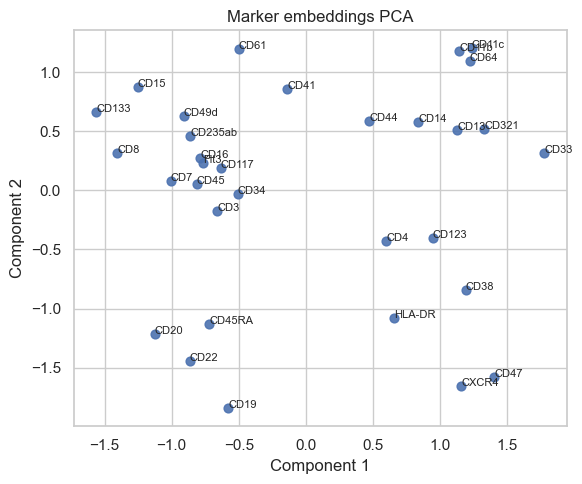

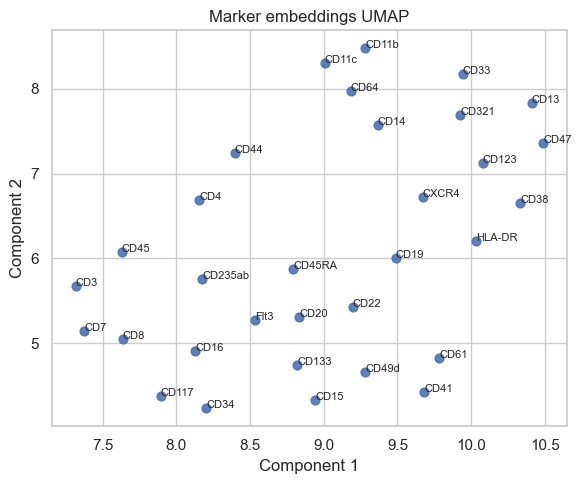

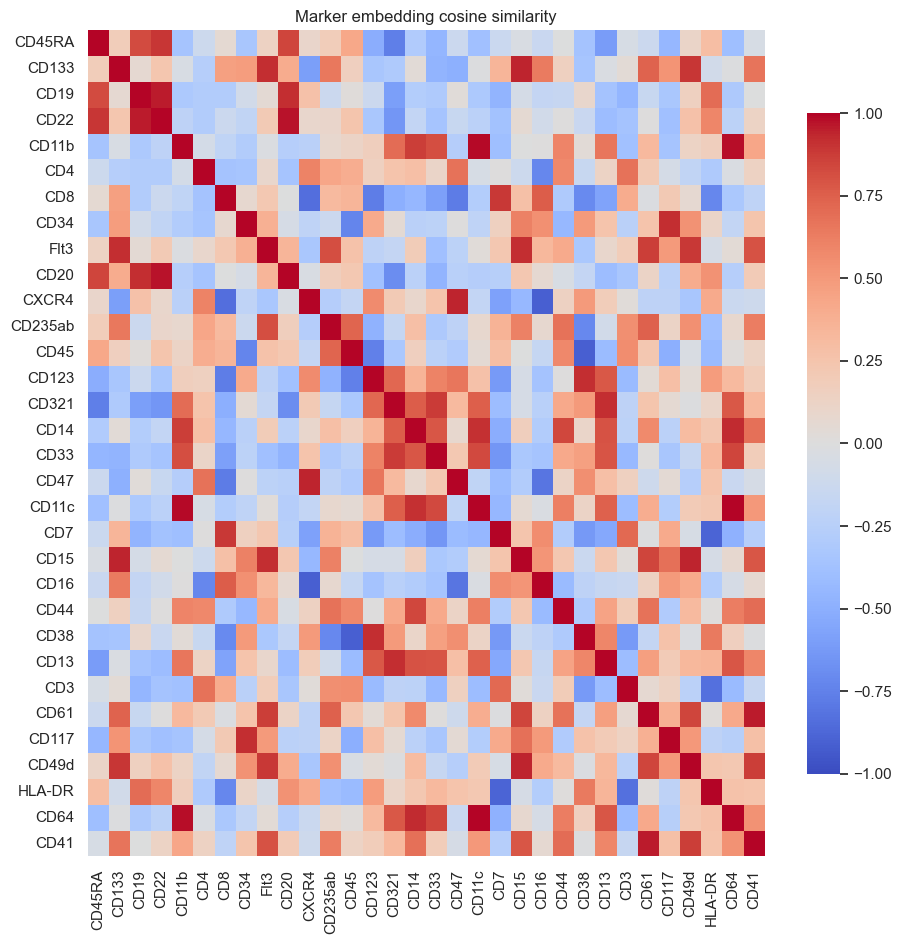

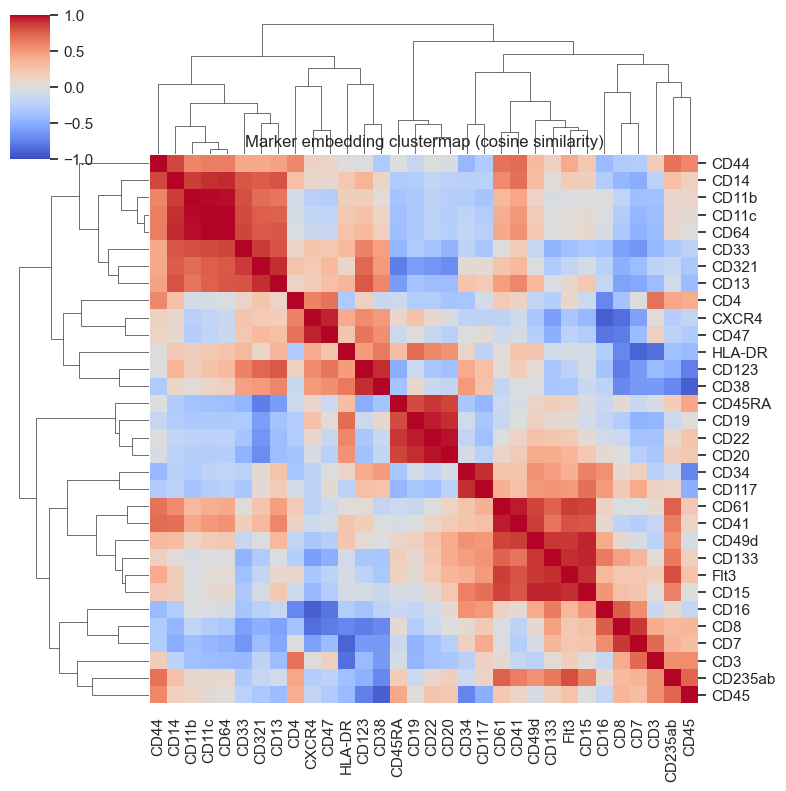

Saved marker nearest-neighbor table to: outputs/archetype_embedding_analysis/marker_embedding_neighbors.csv


,query,rank,neighbor,similarity
0,CD45RA,1,CD22,0.894025
1,CD45RA,2,CD20,0.848263
2,CD45RA,3,CD19,0.825399
3,CD45RA,4,CD45,0.427765
4,CD45RA,5,HLA-DR,0.291553
5,CD45RA,6,CD235ab,0.187443
6,CD45RA,7,CD133,0.182015
7,CD45RA,8,Flt3,0.134715
8,CD133,1,CD15,0.941441
9,CD133,2,Flt3,0.916687


In [50]:
# === G) Marker embedding analysis (E) ===
E = run.get("E")
if E is None:
    print("This run uses direct decoder; marker embedding matrix E is unavailable.")
else:
    E_pca = pca_projection(E, n_components=2)
    plot_embedding_scatter(E_pca, labels=marker_names, title="Marker embeddings PCA")

    E_umap = umap_projection(E, n_neighbors=min(10, max(2, E.shape[0] - 1)), min_dist=0.1, random_state=7)
    if E_umap is not None:
        plot_embedding_scatter(E_umap, labels=marker_names, title="Marker embeddings UMAP")
    else:
        print("umap-learn not installed; skipping marker embedding UMAP.")

    marker_sim = cosine_similarity_matrix(E)
    plot_matrix_heatmap(
        marker_sim,
        row_labels=marker_names,
        col_labels=marker_names,
        title="Marker embedding cosine similarity",
        cmap="coolwarm",
        figsize=(max(8, len(marker_names) * 0.3), max(6, len(marker_names) * 0.3)),
        vmin=-1,
        vmax=1,
    )

    plot_clustermap(
        marker_sim,
        row_labels=marker_names,
        col_labels=marker_names,
        title="Marker embedding clustermap (cosine similarity)",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        figsize=(max(7, len(marker_names) * 0.25), max(7, len(marker_names) * 0.25)),
        metric="euclidean",
        method="average",
    )

    nn_df = nearest_neighbors_from_similarity(marker_sim, marker_names, k=min(8, max(1, len(marker_names) - 1)))
    nn_path = ANALYSIS_OUTDIR / "marker_embedding_neighbors.csv"
    nn_df.to_csv(nn_path, index=False)
    print(f"Saved marker nearest-neighbor table to: {nn_path}")
    display(nn_df.head(40))


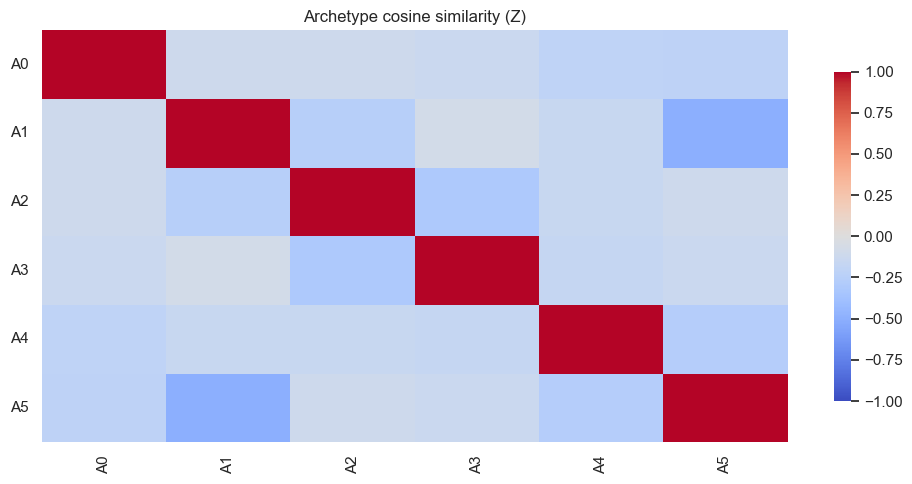

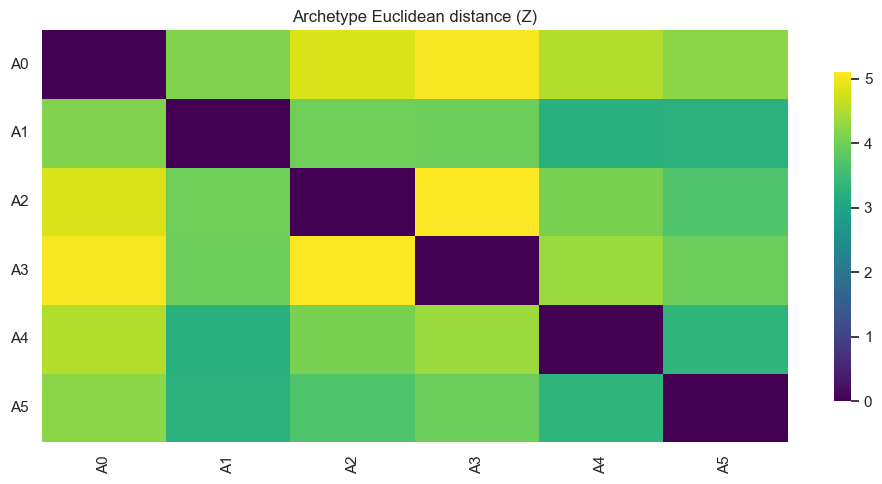

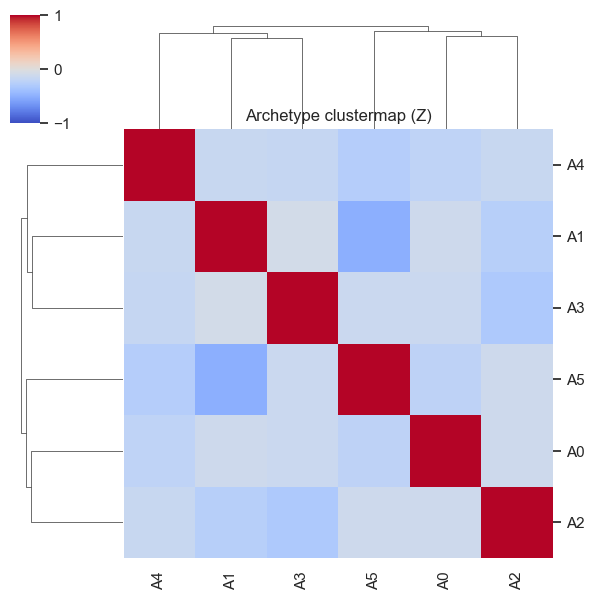

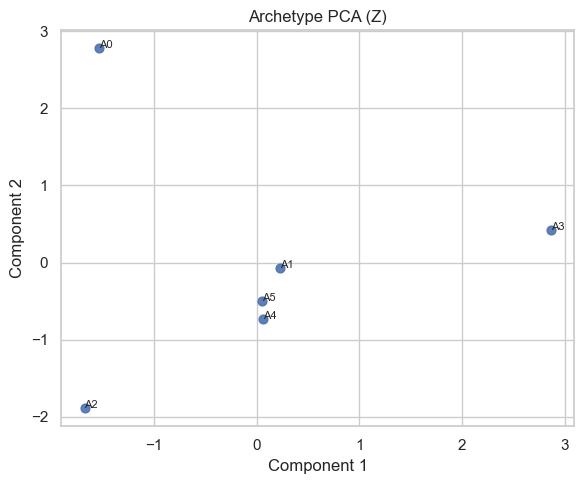

In [51]:
# === H) Archetype embedding analysis (Z) ===
if run.get("Z") is not None:
    archetype_repr = run["Z"]
    repr_name = "Z"
else:
    archetype_repr = A_hat
    repr_name = "A_hat (direct archetype profiles)"

arch_sim = cosine_similarity_matrix(archetype_repr)
arch_dist = pairwise_distance_matrix(archetype_repr)

labels = [f"A{k}" for k in range(archetype_repr.shape[0])]
plot_matrix_heatmap(arch_sim, row_labels=labels, col_labels=labels, title=f"Archetype cosine similarity ({repr_name})", cmap="coolwarm", vmin=-1, vmax=1)
plot_matrix_heatmap(arch_dist, row_labels=labels, col_labels=labels, title=f"Archetype Euclidean distance ({repr_name})", cmap="viridis")

plot_clustermap(
    arch_sim,
    row_labels=labels,
    col_labels=labels,
    title=f"Archetype clustermap ({repr_name})",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    figsize=(6, 6),
    metric="euclidean",
    method="average",
)

arch_pca = pca_projection(archetype_repr, n_components=2)
plot_embedding_scatter(arch_pca, labels=labels, title=f"Archetype PCA ({repr_name})")


Saved residual summary to: outputs/archetype_embedding_analysis/residual_marker_summary.csv


,marker,residual_mean,residual_std,residual_mae,residual_mse
0,Flt3,0.008984,0.940677,0.546881,0.884955
1,CD16,-0.000728,0.938125,0.483115,0.880080
2,CD123,-0.000137,0.871780,0.492884,0.760000
3,CD133,0.010643,0.850758,0.606068,0.723902
4,CD235ab,0.006797,0.850646,0.622637,0.723644
5,CD14,-0.012035,0.841497,0.521311,0.708262
6,CD45RA,-0.008157,0.841306,0.657619,0.707862
7,CXCR4,-0.008556,0.818789,0.653593,0.670489
8,CD15,0.009482,0.802033,0.576468,0.643346
9,CD7,-0.004297,0.785055,0.549075,0.616330


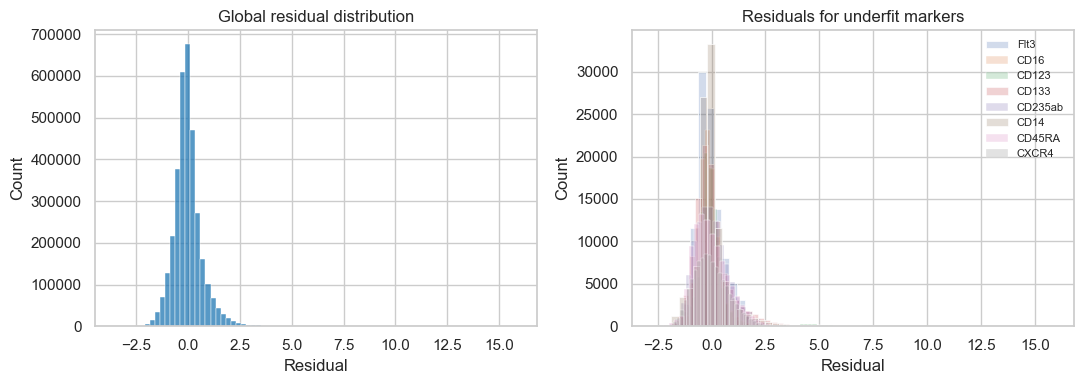

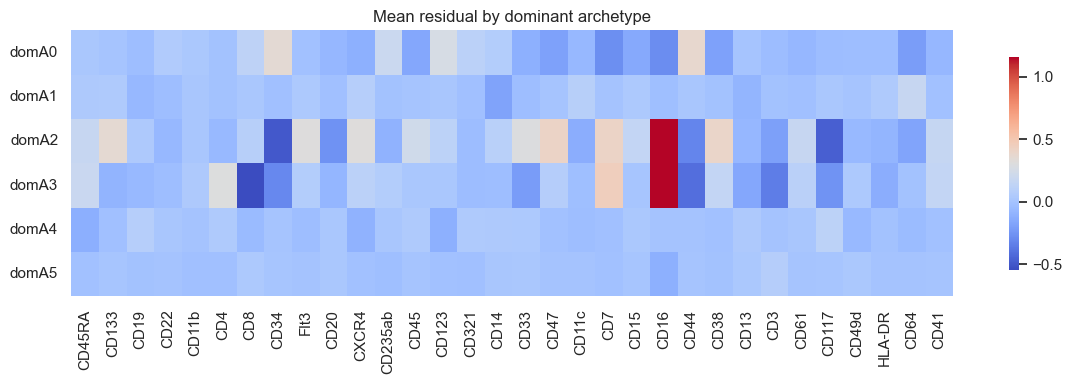

In [52]:
# === I) Residual analysis ===
res_df = residual_summary(X, X_hat, marker_names)
res_path = ANALYSIS_OUTDIR / "residual_marker_summary.csv"
res_df.to_csv(res_path, index=False)
print(f"Saved residual summary to: {res_path}")

display(res_df.head(25))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot((X - X_hat).ravel(), bins=80, ax=axes[0], color="tab:blue")
axes[0].set_title("Global residual distribution")
axes[0].set_xlabel("Residual")

worst_markers = res_df.head(min(8, len(res_df)))["marker"].tolist()
idx_map = {m: i for i, m in enumerate(marker_names)}
for marker in worst_markers:
    m = idx_map[marker]
    sns.histplot((X[:, m] - X_hat[:, m]), bins=50, ax=axes[1], alpha=0.25, label=marker)
axes[1].set_title("Residuals for underfit markers")
axes[1].set_xlabel("Residual")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()

# Optional residual heatmap by dominant archetype.
residual = X - X_hat
dom = np.argmax(W, axis=1)
res_by_dom = np.vstack([residual[dom == k].mean(axis=0) if np.any(dom == k) else np.zeros(X.shape[1]) for k in range(W.shape[1])])
plot_matrix_heatmap(
    res_by_dom,
    row_labels=[f"domA{k}" for k in range(W.shape[1])],
    col_labels=marker_names,
    title="Mean residual by dominant archetype",
    cmap="coolwarm",
    figsize=(max(12, len(marker_names) * 0.35), max(4, W.shape[1] * 0.3)),
)
